<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h1>Artificial Neural Networks</h1>

<h2>The perceptron</h2>
<p>A perceptron is a unit of calculation in DL architectures. It takes an array of inputs each multiplied with a corresponding weights, and produces the sum of them as the output. We can think of it as dot producting two vectors, one of inputs and one of weights.<br>
This is referred to as a linear model. Linear models are only useful for solving linearly separable problems.<br>
If the model incorporates other calculations, it is non-linear. The non-linearity is denoted as sigma, and is applied to the calculated some, as shown on the equation below:</p>

$$ \hat{y} = \sigma(x^{T}w + b) $$

<p>The non-linear function is usually called the activation function. The parameter "b" is the so-called bias-term.</p>

<p>The most common activation functions are Sigmoid, hyperboloic tangent and ReLU.</p>

<img src="../../assets/dudl-03-activation-func.webp">

<p>The "y-hat" term is the predicted outcome. The actual reality is denoted as y. The difference between the predicted outcome and reality is the loss or cost of the model. For calculating the loss, we have a number of Loss Functions. Common examples:
<ul>
<li>Mean-squared error (MSE) is suitable for continuous values:

$$ \mathcal{L} = \frac{1}{2}(\hat{y}-y)^2 $$

</li>
<li>Cross-entropy is suitable for logictic values:

$$ \mathcal{L} = -(y \cdot log(\hat{y}) + (1 - y) \cdot log(1 - \hat{y})) $$

</li>
</ul>
The sum of the losses is called the cost function. The goal of DL is to find the set of weights that minimize the cost function. The training process is going via backpropagation, which utilizes gradient descent.<br>A deep learning network is perceptrons organized into layers.</p>

<img src="../../assets/dudl-03-ann.png">

</div>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

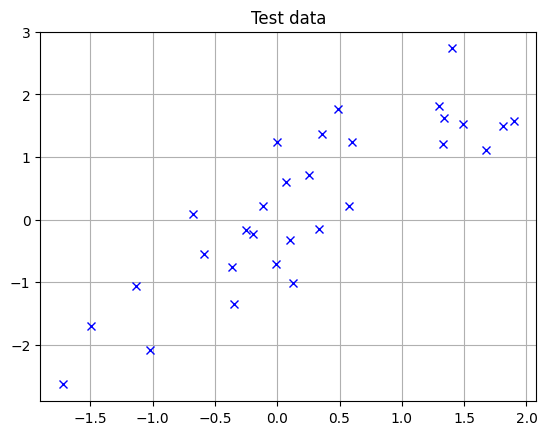

In [17]:
# ANN for regression example
# y_i = beta_0 + beta_1 * x_i + epsilon_i
# epsilon_i is the residual term, the difference between the prediction and the actual data.

N = 30
x = torch.randn(N, 1)
y = x + torch.randn(N, 1) / 2

plt.plot(x, y, 'bx')
plt.grid()
plt.title('Test data')
plt.show()

In [18]:
# building a model
ANNreg = nn.Sequential(
    nn.Linear(1,1), # input layer (1 input on the input side, and 1 output towards the activation function)
    nn.ReLU(),      # activation function
    nn.Linear(1,1)  # output layer (1 input from the activation function and 1 output)
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [19]:
learningRate = 0.05
lossFunction = nn.MSELoss()
epochs = 500

# optimizer is the "flavor" of gradient descent.
# SGD stands for stochastic gradient descent.
optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learningRate)

losses = torch.zeros(epochs)

for i in range(epochs):
    #forward pass
    yHat = ANNreg(x)

    # compute losses
    loss = lossFunction(yHat, y)
    losses[i] = loss

    # back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

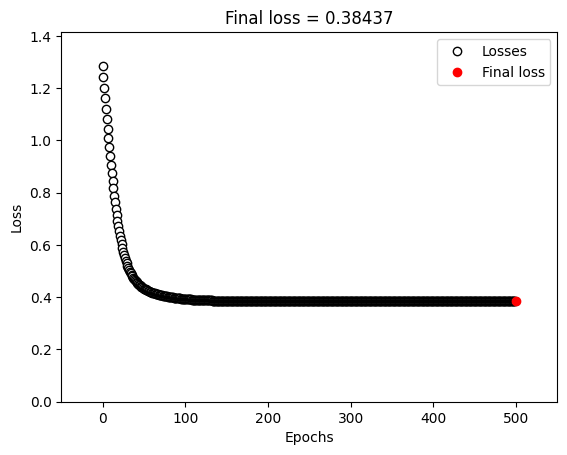

In [20]:
testLoss = (ANNreg(x)-y).pow(2).mean()

plt.plot(losses.detach(), 'ko', markerfacecolor='w', linewidth=.1)
plt.plot(epochs, testLoss.detach(), 'ro')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.xlim([-50, 550])
plt.ylim([0, losses.detach().max()*1.1])
plt.title('Final loss = %g'%testLoss.item())
plt.legend(['Losses', 'Final loss'])
plt.show()

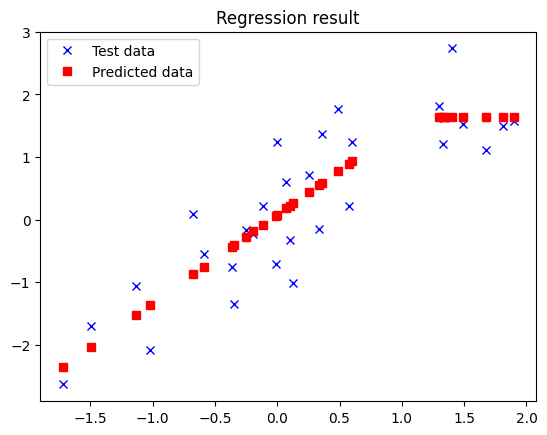

In [21]:
plt.plot(x, y, 'bx')
plt.plot(x, ANNreg(x).detach(), 'rs')

plt.title('Regression result')
plt.legend(['Test data', 'Predicted data'])
plt.show()

<link rel="stylesheet" href="../../styles.css">
<div class="note">
<h2>ANN example for classification</h2>
</div>

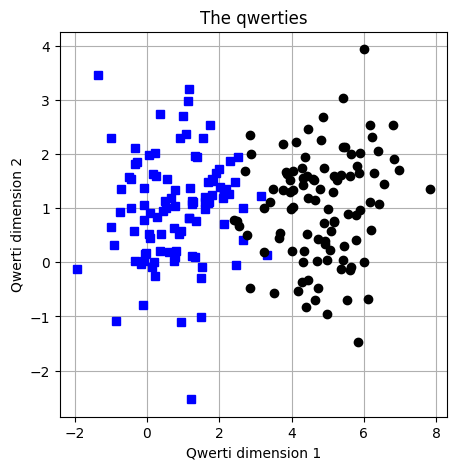

In [23]:
nPerClust = 100
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]

a = [A[0] + np.random.randn(nPerClust)*blur, A[1] + np.random.randn(nPerClust)*blur]
b = [B[0] + np.random.randn(nPerClust)*blur, B[1] + np.random.randn(nPerClust)*blur]

labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1))))
data_np = np.hstack((a, b)).T

labels = torch.tensor(labels_np).float()
data = torch.tensor(data_np).float()

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bs')
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko')
plt.title('The qwerties')
plt.xlabel('Qwerti dimension 1')
plt.ylabel('Qwerti dimension 2')
plt.grid()
plt.show()

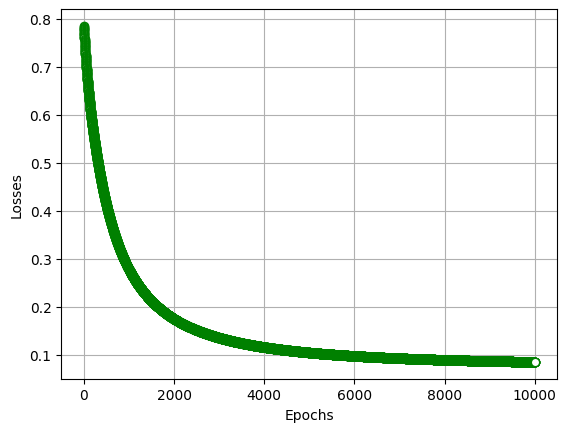

In [32]:
ANNclassify = nn.Sequential(
    nn.Linear(2,1), # Input layer (2 inputs (x,y coordinates), 1 output)
    nn.ReLU(),      # Activation function
    nn.Linear(1,1), # Output layer
    nn.Sigmoid(),   # Final activation function
)

learningRate = 0.01
epochs = 10000
lossFunction = nn.BCELoss() # BCE: Binary Classification Error
optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)

losses = torch.zeros(epochs)
for i in range(epochs):
    # forward pass
    yHat = ANNclassify(data)

    # compute losses
    loss = lossFunction(yHat, labels)
    losses[i] = loss

    # backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.plot(losses.detach(), 'go', markerfacecolor='w', linewidth=.1)
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.grid()

plt.show()

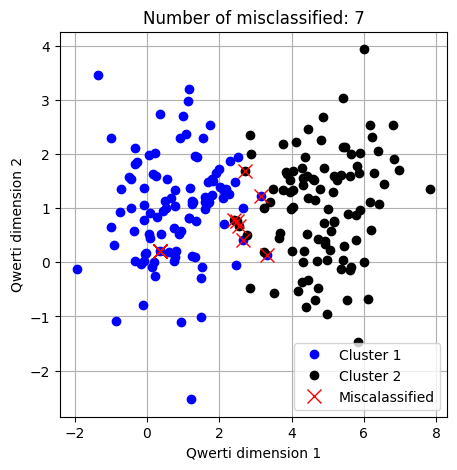

In [57]:
predictedData = ANNclassify(data)
predictedLabels = predictedData > 0.5

miscalassified = [data[np.where(label != predictedLabels),0], data[np.where(label != predictedLabels),1]]

fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0], data[np.where(labels==0)[0],1], 'bo')
plt.plot(data[np.where(labels==1)[0],0], data[np.where(labels==1)[0],1], 'ko')
plt.plot(miscalassified[0], miscalassified[1], 'rx', markersize=10)
plt.title(f'Number of misclassified: {np.shape(miscalassified)[2]}')
plt.xlabel('Qwerti dimension 1')
plt.ylabel('Qwerti dimension 2')
plt.grid()
plt.legend(['Cluster 1', 'Cluster 2', 'Miscalassified'])
plt.show()